In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Processing burst 1/4536: FRB20180725A
Processing burst 2/4536: FRB20180727A
Processing burst 3/4536: FRB20180729A
Processing burst 4/4536: FRB20180729B
Processing burst 5/4536: FRB20180730A
Processing burst 6/4536: FRB20180801A
Processing burst 7/4536: FRB20180806A
Processing burst 8/4536: FRB20180810A
Processing burst 9/4536: FRB20180810B
Processing burst 10/4536: FRB20180812A
Processing burst 11/4536: FRB20180814A
Processing burst 12/4536: FRB20180814B
Processing burst 13/4536: FRB20180817A
Processing burst 14/4536: FRB20180904A
Processing burst 15/4536: FRB20180906A
Processing burst 16/4536: FRB20180906B
Processing burst 17/4536: FRB20180907A
Processing burst 18/4536: FRB20180907B
Processing burst 19/4536: FRB20180907C
Processing burst 20/4536: FRB20180907D
Processing burst 21/4536: FRB20180907E
Processing burst 22/4536: FRB20180908B
Processing burst 23/4536: FRB20180909A
Processing burst 24/4536: FRB20180910A
Processing burst 25/4536: FRB20180911A
Processing burst 26/4536: FRB20180

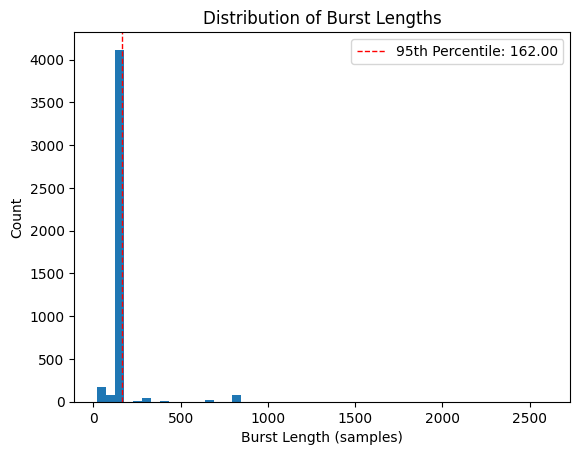

In [2]:
all_bursts = h5py.File("all_bursts.hdf5", "r")

burst_lengths = []

for i, (key, burst) in enumerate(all_bursts.items()):
    print(f"Processing burst {i+1}/{len(all_bursts)}: {key}")
    length = list(burst["wfall_plot"].shape)[1]
    burst_lengths.append(length)
    

p95 = np.percentile(burst_lengths, 95)
print(p95)


# make a histogram of burst lengths
plt.hist(burst_lengths, bins=50)
plt.xlabel("Burst Length (samples)")
plt.ylabel("Count")
plt.title("Distribution of Burst Lengths")  
plt.axvline(p95, color='r', linestyle='dashed', linewidth=1, label=f'95th Percentile: {p95:.2f}')
plt.legend()

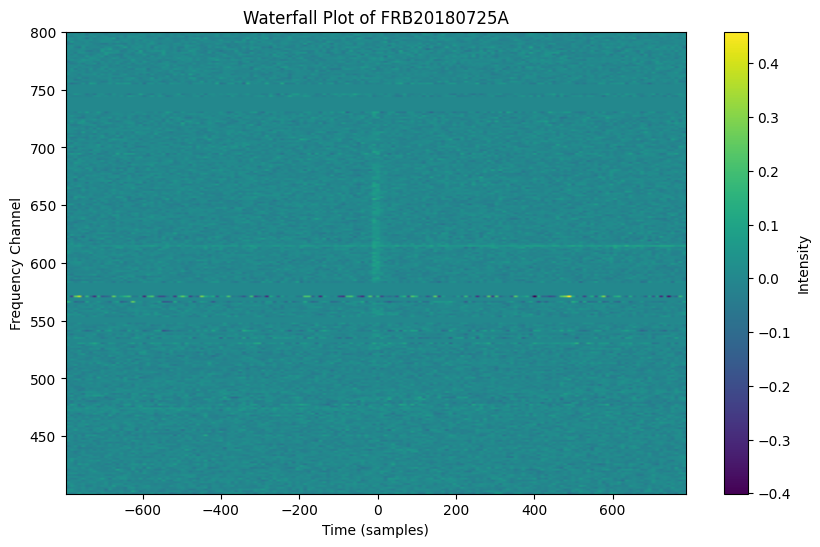

Peak index (t=0) in the extent: 81 samples


In [18]:
# print wfall plot of FRB20180725A

data = all_bursts["FRB20180725A"]["wfall_plot"]
extent = np.array(all_bursts["FRB20180725A"]["extent"])
plt.figure(figsize=(10, 6))
plt.imshow(data, aspect='auto', origin='lower', extent=extent, cmap='viridis')
plt.colorbar(label='Intensity')
plt.xlabel('Time (samples)')
plt.ylabel('Frequency Channel')
plt.title('Waterfall Plot of FRB20180725A')
plt.show()


# get index where t = 0 in the extent, extent is [t_min, t_max, f_min, f_max]

dt = 0.009830400085775182*1000

peak = round(-extent[0] / dt)

print(f"Peak index (t=0) in the extent: {peak} samples")